In [1]:
"""
Re‑creates your current world + camera demo and opens a matplotlib window.
Run:  python -m examples.demo_world
"""
import numpy as np
import torch

from nerflab import (
    Intrinsics, Camera, Box, Sphere, World, plot_world, CFG, pose_H, make_pose_cases, save_world, World, Box, Sphere
)

In [2]:
# build preset dictionary
cases = make_pose_cases(axis_dist=3)

# pick a view (e.g., diagonal)
H_wc = pose_H(cases["+Z"])  
# H_wc = np.eye(4)
print(H_wc)

tensor([[1., 0., -0., 0.],
        [-0., 1., -0., 0.],
        [0., 0., 1., 3.],
        [0., 0., 0., 1.]])


In [3]:
# --- camera ------------------------------------------------------------------
# H_wc = np.eye(4, dtype=np.float32)        # simple origin‑facing camera
cam   = Camera(H_wc)

# --- sample rays -------------------------------------------------------------
O_w, D_w = cam.get_rays(frame="world")
t, delta, pts = cam.sample_along_rays(O_w, D_w, rng=torch.manual_seed(0))
print("points shape:", pts.shape)


points shape: torch.Size([307200, 40, 3])


density at (0,2,1): tensor(0.)


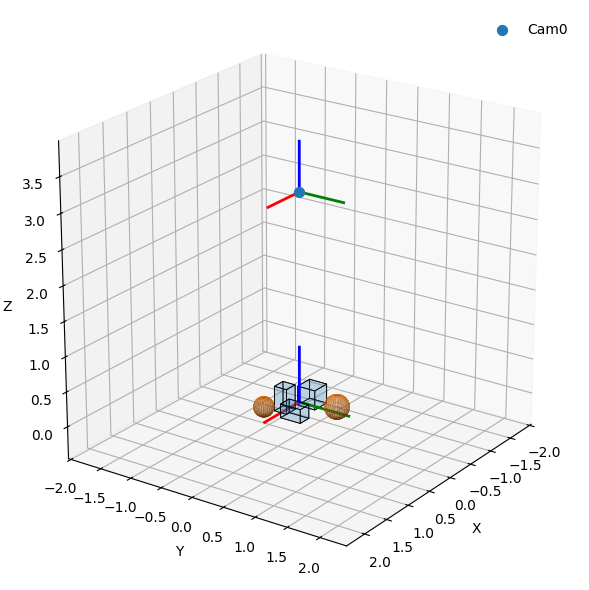

In [4]:
# --- build world -------------------------------------------------------------
# ------------------------------------------------------------
# Scaled‑down world  (factor = 0.20)
# ------------------------------------------------------------
world = World()

# Boxes
world.add_shape(Box(center=(-0.30,  0.00, 0.0), size=(0.28, 0.28, 0.28)))
world.add_shape(Box(center=( 0.28,  0.12, 0.0), size=(0.20, 0.32, 0.20)))
world.add_shape(Box(center=( 0.00, -0.24, 0.0), size=(0.20, 0.20, 0.36)))

# Spheres
world.add_shape(Sphere(center=(-0.16,  0.50, 0.0), radius=0.17))
world.add_shape(Sphere(center=( 0.40, -0.30, 0.0), radius=0.14))

# Check the density of a point
x,y,z = (0.0,2.0,1.0)
print("density at (0,2,1):", world.density(torch.tensor([x, y, z])))


plot_world(
    world,
    cameras=cam,
)

save_world(world, "../data/world.json")

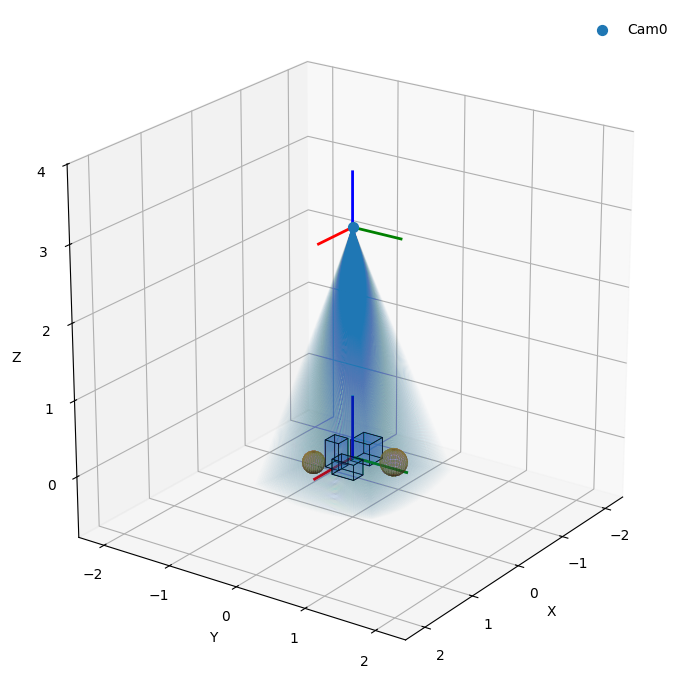

(<Figure size 900x700 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>)

In [5]:
from nerflab.viz import viz_cfg
viz_cfg.figsize = (9, 7)
viz_cfg.default_alpha = 0.5
# --- visualise ---------------------------------------------------------------
plot_world(world, cameras=[cam], draw_rays=True, ray_alpha=0.01)

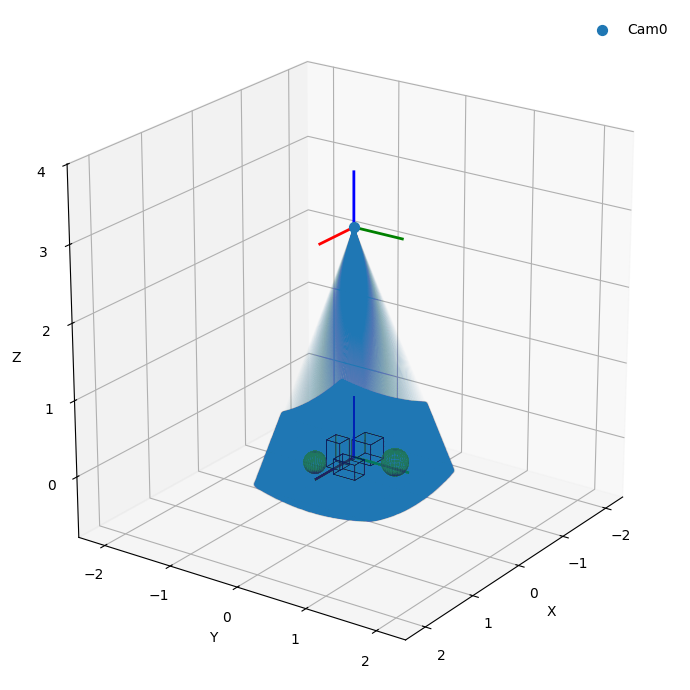

(<Figure size 900x700 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>)

In [6]:

plot_world(
    world,
    cameras=[cam],
    draw_rays=True,          # we’ll show only the cloud
    ray_mode="lines",
    external_points=pts,
    external_point_size=4,
    ray_alpha=0.01,
    samples_alpha=0.01

)


In [7]:
O_w.shape

torch.Size([307200, 3])

In [8]:
pts.shape

torch.Size([307200, 40, 3])

In [9]:
cam.print_info()

=== Camera ===
Res: 480 x 640
fx, fy: 1194.26, 895.69
cx, cy: 320.00, 240.00
t_bounds: [2.5, 3.5]
H_wc shape: (4, 4)


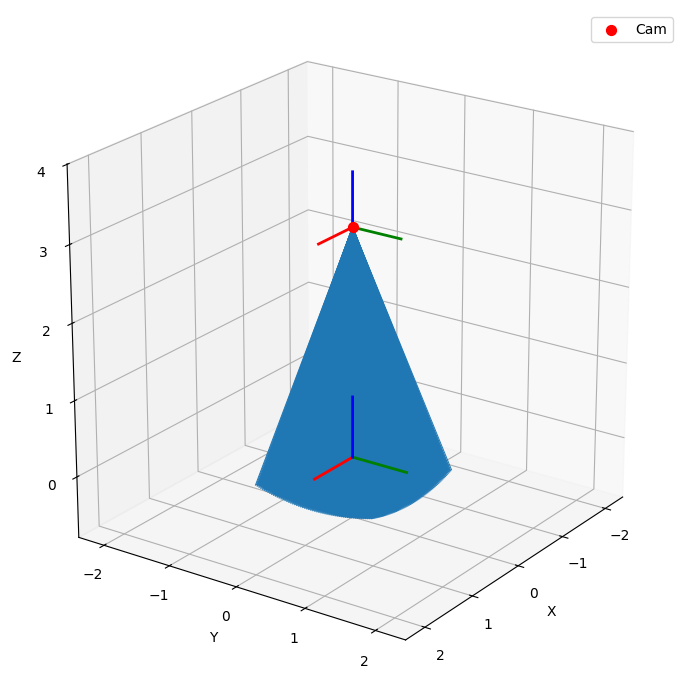

In [10]:
cam.plot_rays()